# Overall Analysis of ABFE Rescoring

In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import rdMolAlign, AllChem
import spyrmsd.molecule
import spyrmsd.rmsd

# Set up plotting style
plt.style.use('ggplot')
%matplotlib inline

## 1. Configuration

Define paths and parameters for the analysis.

In [2]:
# Define base directories
BASE_DIR = Path(".").absolute() 
ABFE_DIR = BASE_DIR / "abfe"  # ABFE results are in parent directory
REFERENCE_SDF = BASE_DIR / "input/test_mers.sdf"
FEGROW_RESULT_DIR = BASE_DIR / "../input/fegrow_result"  # Original SDF files

# Parameters
RMSD_THRESHOLD = 2.0  # Angstroms -- threshold below which we consider a pose to be close to the reference.

## 2. Parse ABFE Results

Read all `overall_stats.dat` files and extract mean free energies. Note that runs for charged molecules will have failed on set-up and are ignored. There were a few other failures due to cluster issues.

In [3]:
def parse_overall_stats(filepath: str) -> dict:
    """
    Parse overall_stats.dat file to extract mean free energy.

    Parameters:
    -----------
    filepath : str
        Path to overall_stats.dat file

    Returns:
    --------
    dict : Dictionary with 'mean_dg' and 'error' keys.

    Raises:
    -------
    FileNotFoundError
        If the file does not exist.
    ValueError
        If the expected mean free energy line is missing.
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"overall_stats.dat not found: {filepath}")

    with open(filepath, 'r') as f:
        content = f.read()

    # Format: "Mean free energy: -14.020 + /- 2.899 kcal/mol"
    match = re.search(r'Mean free energy:\s*([-\d.]+)\s*\+\s*/\-\s*([-\d.]+)', content)
    if not match:
        raise ValueError(f"Could not parse mean free energy from: {filepath}")

    return {
        'mean_dg': float(match.group(1)),
        'error': float(match.group(2))
    }

# Test the function
test_file = BASE_DIR / "abfe/mol3/rec_final_1/output/overall_stats.dat"
result = parse_overall_stats(test_file)
print(f"Test parse result: {result}")

Test parse result: {'mean_dg': -15.023, 'error': 3.908}


In [4]:
def collect_abfe_results(abfe_dir: str, fegrow_dir: str) -> pd.DataFrame:
    """
    Collect all ABFE results from directory structure.

    Parameters:
    -----------
    abfe_dir : str
        Base directory containing mol*/rec_final_* subdirectories
    fegrow_dir : str
        Directory containing original SDF files from fegrow

    Returns:
    --------
    pd.DataFrame : DataFrame with columns [mol_id, receptor_id, mean_dg, error, stats_path, ligand_sdf_path]

    Raises:
    -------
    ValueError
        If any expected mapping/parsing step fails.
    """
    results = []
    
    abfe_dir = Path(abfe_dir)
    fegrow_dir = Path(fegrow_dir)

    # Pattern: abfe/mol*/rec_final_*/output/overall_stats.dat
    stats_pattern = str(abfe_dir / "mol*/rec_final_*/output/overall_stats.dat")
    stats_files = glob.glob(stats_pattern)

    if not stats_files:
        raise ValueError(f"No overall_stats.dat files found for pattern: {stats_pattern}")

    print(f"Found {len(stats_files)} overall_stats.dat files")

    for stats_file in sorted(stats_files):
        stats_file_path = Path(stats_file)
        parts = stats_file_path.parts

        mol_id = None
        receptor_id = None
        mol_idx = None
        rec_idx = None
        for i, part in enumerate(parts):
            if part.startswith('mol'):
                mol_id = part
                mol_idx = i
            if part.startswith('rec_final_'):
                receptor_id = part
                rec_idx = i

        if mol_id is None or receptor_id is None:
            raise ValueError(f"Could not extract mol/rec from {stats_file}")

        stats = parse_overall_stats(stats_file)

        mol_dir = Path(*parts[:mol_idx + 1])
        rec_dir = Path(*parts[:rec_idx + 1])

        csv_path = mol_dir / "mol_scores_sorted.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"Missing mol_scores_sorted.csv: {csv_path}")

        mol_csv = pd.read_csv(csv_path)
        for required_col in ("receptor", "ligand"):
            if required_col not in mol_csv.columns:
                raise ValueError(f"Missing column '{required_col}' in {csv_path}")

        rec_num = receptor_id.replace('rec_final_', '')
        expected_receptor_name = f"rec_final_{rec_num}.pdb"
        matching_rows = mol_csv[mol_csv['receptor'].astype(str) == expected_receptor_name]

        if len(matching_rows) != 1:
            raise ValueError(
                f"Expected exactly 1 row for receptor '{expected_receptor_name}' in {csv_path}, found {len(matching_rows)}"
            )

        ligand_filename = matching_rows.iloc[0]['ligand']
        if pd.isna(ligand_filename) or not str(ligand_filename).strip():
            raise ValueError(f"Empty ligand filename for {mol_id}/{receptor_id} in {csv_path}")

        ligand_sdf_path = fegrow_dir / str(ligand_filename)
        if not ligand_sdf_path.exists():
            raise FileNotFoundError(f"SDF file not found: {ligand_sdf_path}")

        results.append({
            'mol_id': mol_id,
            'receptor_id': receptor_id,
            'mean_dg': stats['mean_dg'],
            'error': stats['error'],
            'stats_path': str(stats_file),
            'ligand_sdf_path': str(ligand_sdf_path),
            'mol_dir': str(mol_dir),
            'rec_dir': str(rec_dir)
        })

    df = pd.DataFrame(results)
    if df.empty:
        raise ValueError("No ABFE results were collected")

    df = df.sort_values(['mol_id', 'mean_dg']).reset_index(drop=True)
    return df

# Collect all ABFE results
abfe_df = collect_abfe_results(ABFE_DIR, FEGROW_RESULT_DIR)
print(f"\nCollected {len(abfe_df)} ABFE calculations")
print(f"Unique molecules: {abfe_df['mol_id'].nunique()}")
print(f"Unique receptors: {abfe_df['receptor_id'].nunique()}")
print(f"SDF files found: {abfe_df['ligand_sdf_path'].notna().sum()}/{len(abfe_df)}")
abfe_df

Found 401 overall_stats.dat files

Collected 401 ABFE calculations
Unique molecules: 27
Unique receptors: 17
SDF files found: 401/401


Found 401 overall_stats.dat files

Collected 401 ABFE calculations
Unique molecules: 27
Unique receptors: 17
SDF files found: 401/401


,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
...,...,...,...,...,...,...,...,...
396,mol9,rec_final_7,-15.170,4.732,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
397,mol9,rec_final_5,-14.872,3.419,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
398,mol9,rec_final_18,-14.150,4.512,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...
399,mol9,rec_final_15,-13.642,3.177,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...


In [5]:
# Print all mol IDs in numeric order (convert to int for sorting)
for mol_id in sorted(abfe_df['mol_id'].unique(), key=lambda x: int(x.replace('mol', ''))):
    print(mol_id)

mol3
mol4
mol7
mol9
mol11
mol12
mol13
mol16
mol17
mol18
mol20
mol21
mol22
mol25
mol26
mol27
mol30
mol33
mol34
mol35
mol36
mol37
mol39
mol40
mol43
mol44
mol45


## 3. Load Reference Structures

Read the true ligand poses from `input/test_mers.sdf`. Each molecule in the SDF will be indexed sequentially.

In [6]:
def load_reference_structures(sdf_path: str) -> dict:
    """
    Load reference structures from SDF file.
    
    Parameters:
    -----------
    sdf_path : str
        Path to reference SDF file
        
    Returns:
    --------
    dict : Dictionary mapping mol_id (e.g., 'mol3', 'mol4') to RDKit molecule objects
    """
    suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
    references = {}
    
    for idx, mol in enumerate(suppl):
        if mol is not None:
            mol_id = f"mol{idx}"  # Assuming numbering starts at mol3
            references[mol_id] = mol
    
    print(f"Loaded {len(references)} reference structures")
    print(f"Molecule IDs: {sorted(references.keys())}")
    
    return references

# Load reference structures
reference_mols = load_reference_structures(REFERENCE_SDF)

# Show first few
for mol_id in sorted(list(reference_mols.keys())[:5]):
    mol = reference_mols[mol_id]
    print(f"{mol_id}: {mol.GetNumAtoms()} atoms")

Loaded 97 reference structures
Molecule IDs: ['mol0', 'mol1', 'mol10', 'mol11', 'mol12', 'mol13', 'mol14', 'mol15', 'mol16', 'mol17', 'mol18', 'mol19', 'mol2', 'mol20', 'mol21', 'mol22', 'mol23', 'mol24', 'mol25', 'mol26', 'mol27', 'mol28', 'mol29', 'mol3', 'mol30', 'mol31', 'mol32', 'mol33', 'mol34', 'mol35', 'mol36', 'mol37', 'mol38', 'mol39', 'mol4', 'mol40', 'mol41', 'mol42', 'mol43', 'mol44', 'mol45', 'mol46', 'mol47', 'mol48', 'mol49', 'mol5', 'mol50', 'mol51', 'mol52', 'mol53', 'mol54', 'mol55', 'mol56', 'mol57', 'mol58', 'mol59', 'mol6', 'mol60', 'mol61', 'mol62', 'mol63', 'mol64', 'mol65', 'mol66', 'mol67', 'mol68', 'mol69', 'mol7', 'mol70', 'mol71', 'mol72', 'mol73', 'mol74', 'mol75', 'mol76', 'mol77', 'mol78', 'mol79', 'mol8', 'mol80', 'mol81', 'mol82', 'mol83', 'mol84', 'mol85', 'mol86', 'mol87', 'mol88', 'mol89', 'mol9', 'mol90', 'mol91', 'mol92', 'mol93', 'mol94', 'mol95', 'mol96']
mol0: 63 atoms
mol1: 51 atoms
mol2: 56 atoms
mol3: 67 atoms
mol4: 41 atoms


In [7]:
# Print the total charges of all reference molecules
for mol_id, mol in reference_mols.items():
    total_charge = sum(atom.GetFormalCharge() for atom in mol.GetAtoms())
    print(f"{mol_id} total charge: {total_charge}")

mol0 total charge: 0
mol1 total charge: 0
mol2 total charge: 1
mol3 total charge: 0
mol4 total charge: 0
mol5 total charge: 0
mol6 total charge: 1
mol7 total charge: 0
mol8 total charge: 0
mol9 total charge: 0
mol10 total charge: 1
mol11 total charge: 0
mol12 total charge: 0
mol13 total charge: 0
mol14 total charge: 1
mol15 total charge: 1
mol16 total charge: 0
mol17 total charge: 0
mol18 total charge: 0
mol19 total charge: 1
mol20 total charge: 0
mol21 total charge: 0
mol22 total charge: 0
mol23 total charge: 1
mol24 total charge: 1
mol25 total charge: 0
mol26 total charge: 0
mol27 total charge: 0
mol28 total charge: 1
mol29 total charge: 1
mol30 total charge: 0
mol31 total charge: 0
mol32 total charge: 1
mol33 total charge: 0
mol34 total charge: 0
mol35 total charge: 0
mol36 total charge: 0
mol37 total charge: 0
mol38 total charge: 1
mol39 total charge: 0
mol40 total charge: 0
mol41 total charge: 0
mol42 total charge: -1
mol43 total charge: 0
mol44 total charge: 0
mol45 total charge:

## 4. Load Ligand Structures from Original SDF Files

Load the original ligand conformations from the SDF files used to generate the ABFE calculations.

In [8]:
def load_ligand_from_sdf(sdf_path: str) -> Chem.Mol:
    """
    Load ligand structure from SDF file.

    Parameters:
    -----------
    sdf_path : str
        Path to SDF file

    Returns:
    --------
    RDKit Mol : Molecule from SDF

    Raises:
    -------
    FileNotFoundError
        If the SDF file does not exist.
    ValueError
        If the SDF cannot be parsed into a molecule.
    """
    if pd.isna(sdf_path) or not isinstance(sdf_path, str) or not sdf_path.strip():
        raise ValueError(f"Invalid SDF path: {sdf_path}")

    sdf_path = Path(sdf_path)
    if not sdf_path.exists():
        raise FileNotFoundError(f"SDF file not found: {sdf_path}")

    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)

    if not len(suppl) == 1:
        raise ValueError(f"Expected exactly one molecule in {sdf_path}, found {len(suppl)}")

    return suppl[0]

# Test with one example
test_mol_id = 'mol3'
if test_mol_id in reference_mols:
    test_row = abfe_df[abfe_df['mol_id'] == test_mol_id].iloc[0]
    test_sdf_mol = load_ligand_from_sdf(test_row['ligand_sdf_path'])
    print(f"Successfully loaded SDF ligand for {test_mol_id}")
    print(f"Number of atoms: {test_sdf_mol.GetNumAtoms()}")
    print(f"SDF path: {test_row['ligand_sdf_path']}")

Successfully loaded SDF ligand for mol3
Number of atoms: 67
SDF path: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/../input/fegrow_result/rec_20_mol3.sdf


## 5. Calculate RMSD for All Structures

Compute RMSD between each ABFE-scored structure and its corresponding reference structure.

In [9]:
def calculate_rmsd_for_dataframe(df: pd.DataFrame, reference_mols: dict) -> pd.DataFrame:
    """
    Calculate RMSD for all entries in the dataframe.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with ABFE results
    reference_mols : dict
        Dictionary of reference molecules

    Returns:
    --------
    pd.DataFrame : DataFrame with added 'rmsd' column

    Raises:
    -------
    ValueError
        If required references/SDF files are missing or RMSD cannot be calculated.
    """
    rmsds = []

    for idx, row in df.iterrows():
        mol_id = row['mol_id']
        receptor_id = row['receptor_id']

        if mol_id not in reference_mols:
            raise ValueError(f"No reference structure for {mol_id}")

        sdf_mol = load_ligand_from_sdf(row['ligand_sdf_path'])

        # Copy molecules and remove hydrogens for RMSD calculation
        sdf_mol = Chem.RemoveHs(sdf_mol)
        ref_mol = Chem.RemoveHs(reference_mols[mol_id])

        # Compute RMSD as done in https://github.com/asapdiscovery/asap-polaris-blind-challenge-examples/blob/56fcb82739721616a1ed6690f826e12befcb42d6/evaluation/ligand_poses.py#L43-L47
        pred_spy = spyrmsd.molecule.Molecule.from_rdkit(sdf_mol)
        refs_spy = spyrmsd.molecule.Molecule.from_rdkit(ref_mol)

        try:
            rmsd_list = spyrmsd.rmsd.rmsdwrapper(refs_spy, pred_spy, symmetry=True, strip=True)
            assert len(rmsd_list) == 1, f"Expected 1 RMSD value, got {len(rmsd_list)}"
            rmsd = rmsd_list[0]
            # 
            # This gives the same result...
            # rmsd =  rdMolAlign.CalcRMS(sdf_mol, ref_mol)
        except Exception as e:
            raise ValueError(
                f"RMSD calculation failed for {mol_id}, {receptor_id}. "
                f"Ligand atoms={sdf_mol.GetNumAtoms()}, reference atoms={ref_mol.GetNumAtoms()}"
            ) from e

        rmsds.append(rmsd)

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{len(df)} entries...")

    df = df.copy()
    df['rmsd'] = rmsds
    return df

# Calculate RMSD for all structures
print("Calculating RMSD for all ABFE structures...")
abfe_df = calculate_rmsd_for_dataframe(abfe_df, reference_mols)

# Show statistics
print(f"\nRMSD Statistics:")
print(f"  Calculated: {abfe_df['rmsd'].notna().sum()}/{len(abfe_df)}")
print(f"  Mean RMSD: {abfe_df['rmsd'].mean():.2f} Å")
print(f"  Median RMSD: {abfe_df['rmsd'].median():.2f} Å")
print(f"  Min RMSD: {abfe_df['rmsd'].min():.2f} Å")
print(f"  Max RMSD: {abfe_df['rmsd'].max():.2f} Å")

abfe_df.head(10)

Calculating RMSD for all ABFE structures...
Processed 20/401 entries...
Processed 40/401 entries...
Processed 60/401 entries...
Processed 80/401 entries...
Processed 100/401 entries...
Processed 120/401 entries...
Processed 140/401 entries...
Processed 160/401 entries...
Processed 180/401 entries...
Processed 200/401 entries...
Processed 220/401 entries...
Processed 240/401 entries...
Processed 260/401 entries...
Processed 280/401 entries...
Processed 300/401 entries...
Processed 320/401 entries...
Processed 340/401 entries...
Processed 360/401 entries...
Processed 380/401 entries...
Processed 400/401 entries...

RMSD Statistics:
  Calculated: 401/401
  Mean RMSD: 3.46 Å
  Median RMSD: 3.44 Å
  Min RMSD: 0.65 Å
  Max RMSD: 6.84 Å


Calculating RMSD for all ABFE structures...
Processed 20/401 entries...
Processed 40/401 entries...
Processed 60/401 entries...
Processed 80/401 entries...
Processed 100/401 entries...
Processed 120/401 entries...
Processed 140/401 entries...
Processed 160/401 entries...
Processed 180/401 entries...
Processed 200/401 entries...
Processed 220/401 entries...
Processed 240/401 entries...
Processed 260/401 entries...
Processed 280/401 entries...
Processed 300/401 entries...
Processed 320/401 entries...
Processed 340/401 entries...
Processed 360/401 entries...
Processed 380/401 entries...
Processed 400/401 entries...

RMSD Statistics:
  Calculated: 401/401
  Mean RMSD: 3.46 Å
  Median RMSD: 3.44 Å
  Min RMSD: 0.65 Å
  Max RMSD: 6.84 Å


,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.121978
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436383
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436613
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.434843
5,mol11,rec_final_15,-12.386,2.205,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436551
6,mol11,rec_final_4,-11.632,4.160,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.435609
7,mol11,rec_final_5,-11.478,2.072,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436637
8,mol11,rec_final_14,-11.039,1.494,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436443
9,mol11,rec_final_11,-8.799,4.430,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436529


In [10]:
# Print the lowest RMSD entry for each molecule
lowest_rmsd_df = abfe_df.loc[abfe_df.groupby('mol_id')['rmsd'].idxmin()]
print("\nLowest RMSD entry for each molecule:")
# Create a new column wich is the last part of the ligand_sdf_path (the filename) for better readability
lowest_rmsd_df['ligand_sdf_filename'] = lowest_rmsd_df['ligand_sdf_path'].apply(lambda x: os.path.basename(x))
print(lowest_rmsd_df[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd', 'ligand_sdf_filename']])

# Print the proportion below RMSD threshold
below_threshold = (lowest_rmsd_df['rmsd'] < RMSD_THRESHOLD).sum()
total = len(lowest_rmsd_df)
print(f"\nProportion of structures with RMSD < {RMSD_THRESHOLD} Å: {below_threshold}/{total} ({below_threshold / total:.2%})")


Lowest RMSD entry for each molecule:
    mol_id   receptor_id  mean_dg   error      rmsd ligand_sdf_filename
11   mol11   rec_final_6   -8.668   3.172  3.378081     rec_6_mol11.sdf
24   mol12  rec_final_15   -9.194   1.329  3.047005    rec_15_mol12.sdf
36   mol13  rec_final_16  -19.371   4.214  1.259628    rec_16_mol13.sdf
48   mol16  rec_final_15  -13.402   1.955  2.894973    rec_15_mol16.sdf
71   mol17  rec_final_12  -11.767   2.814  1.241868    rec_12_mol17.sdf
80   mol18  rec_final_19  -12.373   1.303  3.466312    rec_19_mol18.sdf
93   mol20   rec_final_5  -15.703   0.833  3.728997     rec_5_mol20.sdf
115  mol21  rec_final_12   -8.143   3.872  0.645330    rec_12_mol21.sdf
133  mol22  rec_final_12   -6.846   2.326  0.808524    rec_12_mol22.sdf
142  mol25  rec_final_11  -16.477   3.514  1.589063    rec_11_mol25.sdf
151  mol26  rec_final_15  -19.001   1.926  2.994860    rec_15_mol26.sdf
169  mol27   rec_final_7  -10.844  11.554  3.818677     rec_7_mol27.sdf
183   mol3   rec_final_5  

In [11]:
# Sanity check we get the same as Asma...
lowest_rmsds_asma = pd.read_csv("lowest_rmsds.csv")
lowest_rmsds_asma

# Get the proportion below RMSD threshold for Asma's data
below_threshold_asma = (lowest_rmsds_asma['RMSD'] < RMSD_THRESHOLD).sum()
total_asma = len(lowest_rmsds_asma)
print(f"\nAsma's data - Proportion of structures with RMSD < {RMSD_THRESHOLD} Å: {below_threshold_asma}/{total_asma} ({below_threshold_asma / total_asma:.2%})")

# Check that we get the same RMSD values as Asma for the lowest RMSD entries. Note "rmsd" in ours vs "RMSD" in Asma's,
# and "ligand_sdf_filename" in ours should be matched to "ligand_filename" in Asma's.
merged = lowest_rmsd_df.merge(lowest_rmsds_asma, left_on='ligand_sdf_filename', right_on='ligand_filename', how='inner')
merged['rmsd_diff'] = merged['rmsd'] - merged['RMSD']
print("\Comparison of RMSD values for lowest RMSD entries:")
print(merged[['ligand_sdf_filename', 'rmsd', 'RMSD', 'rmsd_diff']])


Asma's data - Proportion of structures with RMSD < 2.0 Å: 76/96 (79.17%)
\Comparison of RMSD values for lowest RMSD entries:
   ligand_sdf_filename      rmsd    RMSD  rmsd_diff
0      rec_6_mol11.sdf  3.378081  3.3781  -0.000019
1     rec_15_mol12.sdf  3.047005  3.0470   0.000005
2     rec_16_mol13.sdf  1.259628  1.2596   0.000028
3     rec_15_mol16.sdf  2.894973  2.8950  -0.000027
4     rec_12_mol17.sdf  1.241868  1.2419  -0.000032
5     rec_19_mol18.sdf  3.466312  3.4663   0.000012
6      rec_5_mol20.sdf  3.728997  3.7290  -0.000003
7     rec_12_mol21.sdf  0.645330  0.6453   0.000030
8     rec_12_mol22.sdf  0.808524  0.8085   0.000024
9     rec_11_mol25.sdf  1.589063  1.5891  -0.000037
10    rec_15_mol26.sdf  2.994860  2.9949  -0.000040
11     rec_7_mol27.sdf  3.818677  3.8187  -0.000023
12      rec_5_mol3.sdf  1.473816  1.4738   0.000016
13    rec_11_mol30.sdf  0.903992  0.9040  -0.000008
14     rec_7_mol33.sdf  2.362825  2.3628   0.000025
15     rec_2_mol34.sdf  0.832892  0.8329  


Asma's data - Proportion of structures with RMSD < 2.0 Å: 76/96 (79.17%)
\Comparison of RMSD values for lowest RMSD entries:
   ligand_sdf_filename      rmsd    RMSD  rmsd_diff
0      rec_6_mol11.sdf  3.378081  3.3781  -0.000019
1     rec_15_mol12.sdf  3.047005  3.0470   0.000005
2     rec_16_mol13.sdf  1.259628  1.2596   0.000028
3     rec_15_mol16.sdf  2.894973  2.8950  -0.000027
4     rec_12_mol17.sdf  1.241868  1.2419  -0.000032
5     rec_19_mol18.sdf  3.466312  3.4663   0.000012
6      rec_5_mol20.sdf  3.728997  3.7290  -0.000003
7     rec_12_mol21.sdf  0.645330  0.6453   0.000030
8     rec_12_mol22.sdf  0.808524  0.8085   0.000024
9     rec_11_mol25.sdf  1.589063  1.5891  -0.000037
10    rec_15_mol26.sdf  2.994860  2.9949  -0.000040
11     rec_7_mol27.sdf  3.818677  3.8187  -0.000023
12      rec_5_mol3.sdf  1.473816  1.4738   0.000016
13    rec_11_mol30.sdf  0.903992  0.9040  -0.000008
14     rec_7_mol33.sdf  2.362825  2.3628   0.000025
15     rec_2_mol34.sdf  0.832892  0.8329  

<>:14: SyntaxWarning: invalid escape sequence '\C'
<>:14: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_1718066/659912169.py:14: SyntaxWarning: invalid escape sequence '\C'
  print("\Comparison of RMSD values for lowest RMSD entries:")


## 5.1 Save out Superimposed Structres for Visualisation

In [12]:
abfe_df

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622
1,mol11,rec_final_20,-15.013,3.051,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.121978
2,mol11,rec_final_19,-14.350,0.983,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436383
3,mol11,rec_final_16,-13.948,0.992,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436613
4,mol11,rec_final_13,-13.370,2.424,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.434843
...,...,...,...,...,...,...,...,...,...
396,mol9,rec_final_7,-15.170,4.732,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.993236
397,mol9,rec_final_5,-14.872,3.419,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.727450
398,mol9,rec_final_18,-14.150,4.512,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,6.656068
399,mol9,rec_final_15,-13.642,3.177,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.738464


In [13]:
from rdkit.Chem import rdMolAlign


def save_superimposed_structures(df: pd.DataFrame, reference_mols: dict, out_dir: Path = None):
    """Save aligned ligand structures (SDF) for each mol_id for visualization.

    For each `mol_id` present in `df`, align each ligand to the corresponding
    reference (from `reference_mols`) and write an SDF containing all aligned
    conformations with metadata fields (receptor_id, mean_dg, error, rmsd).
    """
    if out_dir is None:
        out_dir = BASE_DIR / "analysis_results" / "superimposed"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for mol_id, grp in df.groupby('mol_id'):
        if mol_id not in reference_mols:
            print(f"Skipping {mol_id}: no reference structure available")
            continue

        ref = reference_mols[mol_id]
        writer_path = out_dir / f"{mol_id}_aligned.sdf"
        writer = Chem.SDWriter(str(writer_path))
        written = 0

        for _, row in grp.sort_values('mean_dg').iterrows():
            try:
                lig = load_ligand_from_sdf(row['ligand_sdf_path'])
            except Exception as e:
                print(f"  Could not load ligand for {mol_id} {row['receptor_id']}: {e}")
                continue

            # Make an editable copy
            lig_copy = Chem.Mol(lig)

            # Attach metadata for downstream visualizers
            lig_copy.SetProp('receptor_id', str(row['receptor_id']))
            lig_copy.SetProp('mean_dg', f"{row['mean_dg']:.4f}")
            lig_copy.SetProp('error', f"{row['error']:.4f}")
            rmsd_val = row.get('rmsd', None)
            lig_copy.SetProp('rmsd', f"{float(rmsd_val):.4f}" if pd.notna(rmsd_val) else "nan")

            writer.write(lig_copy)

            # Also save out the correct reference structure for visual comparison
            with Chem.SDWriter(str(out_dir / f"{mol_id}_reference.sdf")) as ref_writer:
                ref_writer.write(ref)

            written += 1

        writer.close()
        print(f"Wrote {written} aligned structures for {mol_id} -> {writer_path}")


# Run the saving for all conformations (change to `best_conformations` if you prefer only top poses)
save_superimposed_structures(abfe_df, reference_mols)
print("All superimposed structures saved to:", str(BASE_DIR / "analysis_results" / "superimposed"))

Wrote 15 aligned structures for mol11 -> /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/superimposed/mol11_aligned.sdf
Wrote 15 aligned structures for mol12 -> /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/superimposed/mol12_aligned.sdf
Wrote 15 aligned structures for mol13 -> /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/superimposed/mol13_aligned.sdf
Wrote 15 aligned structures for mol16 -> /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/superimposed/mol16_aligned.sdf
Wrote 16 aligned structures for mol17 -> /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/superimposed/mol17_aligned.sdf
Wrote 15 aligned structures for mol18 -> /home/campus.n

## 5.2 Normalize ABFE Values

For each ligand, offset the ABFE values so that the mean is centered at 0. This allows for better comparison of relative binding energies across different ligands.

In [14]:
# Calculate mean ABFE for each molecule and create normalized column
abfe_df['mean_dg_normalized'] = abfe_df.groupby('mol_id')['mean_dg'].transform(lambda x: x - x.mean())

# Verify normalization
print("Normalized ABFE Statistics:")
for mol_id in sorted(abfe_df['mol_id'].unique(), key=lambda x: int(x.replace('mol', ''))):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id]
    original_mean = mol_data['mean_dg'].mean()
    normalized_mean = mol_data['mean_dg_normalized'].mean()
    print(f"{mol_id}: Original mean = {original_mean:.2f}, Normalized mean = {normalized_mean:.2e}")

print(f"\nOverall normalized mean: {abfe_df['mean_dg_normalized'].mean():.2e}")
print(f"Overall normalized std: {abfe_df['mean_dg_normalized'].std():.2f}")

Normalized ABFE Statistics:
mol3: Original mean = -18.19, Normalized mean = 1.54e-15
mol4: Original mean = -12.34, Normalized mean = 1.18e-16
mol7: Original mean = -8.19, Normalized mean = -1.78e-16
mol9: Original mean = -17.12, Normalized mean = -1.27e-16
mol11: Original mean = -10.94, Normalized mean = 1.78e-16
mol12: Original mean = -11.00, Normalized mean = 1.13e-15
mol13: Original mean = -17.09, Normalized mean = 5.92e-16
mol16: Original mean = -9.50, Normalized mean = 4.74e-16
mol17: Original mean = -14.58, Normalized mean = -2.22e-16
mol18: Original mean = -9.50, Normalized mean = 4.74e-16
mol20: Original mean = -12.19, Normalized mean = -1.72e-15
mol21: Original mean = -12.46, Normalized mean = -4.10e-16
mol22: Original mean = -13.00, Normalized mean = -1.11e-16
mol25: Original mean = -15.75, Normalized mean = -7.11e-16
mol26: Original mean = -13.42, Normalized mean = 9.47e-16
mol27: Original mean = -10.60, Normalized mean = -2.96e-16
mol30: Original mean = -18.60, Normalized m

## 6. Identify Top-Scored Conformations

For each ligand, select the conformation with the lowest (most favorable) ABFE free energy.

In [15]:
# Get the best (lowest dG) conformation for each molecule
best_conformations = abfe_df.loc[abfe_df.groupby('mol_id')['mean_dg'].idxmin()].copy()

print(f"Top-scored conformations for {len(best_conformations)} molecules:")
print(best_conformations[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd']].to_string())

# Statistics for best conformations
print(f"\nBest Conformation Statistics:")
print(f"  Mean dG: {best_conformations['mean_dg'].mean():.2f} ± {best_conformations['mean_dg'].std():.2f} kcal/mol")
print(f"  Mean RMSD: {best_conformations['rmsd'].mean():.2f} ± {best_conformations['rmsd'].std():.2f} Å")
print(f"  RMSD < {RMSD_THRESHOLD} Å: {(best_conformations['rmsd'] < RMSD_THRESHOLD).sum()}/{len(best_conformations)}")

Top-scored conformations for 27 molecules:
    mol_id   receptor_id  mean_dg  error      rmsd
0    mol11   rec_final_9  -15.965  1.909  3.436622
15   mol12  rec_final_19  -16.983  1.512  3.269045
30   mol13  rec_final_19  -25.721  4.363  2.789005
45   mol16   rec_final_6  -16.883  2.751  3.303210
60   mol17  rec_final_20  -23.388  2.626  1.720725
76   mol18   rec_final_5  -15.292  1.674  4.744541
91   mol20   rec_final_4  -17.820  1.891  3.946047
106  mol21  rec_final_19  -19.188  2.950  0.654244
119  mol22  rec_final_19  -17.793  2.615  2.308421
135  mol25  rec_final_20  -23.987  0.891  2.439176
150  mol26  rec_final_19  -19.198  2.931  4.152537
165  mol27   rec_final_9  -19.541  1.426  4.376638
180   mol3  rec_final_20  -23.409  2.567  2.743649
195  mol30  rec_final_20  -27.422  4.475  1.263781
209  mol33   rec_final_6  -17.160  1.405  3.363517
224  mol34   rec_final_1  -18.864  2.437  4.268528
238  mol35  rec_final_13  -24.934  2.559  4.878579
253  mol36   rec_final_4  -22.529  3.83

## 7. Success Rate Analysis

Calculate the percentage of top-scored molecules that are within the RMSD threshold.

In [16]:
successful = best_conformations['rmsd'] < RMSD_THRESHOLD
success_rate = successful.sum() / len(best_conformations) * 100

print(f"="*60)
print(f"SUCCESS RATE ANALYSIS")
print(f"="*60)
print(f"RMSD Threshold: {RMSD_THRESHOLD} Å")
print(f"Total molecules with predictions: {len(best_conformations)}")
print(f"Molecules with RMSD < {RMSD_THRESHOLD} Å: {successful.sum()}")
print(f"Success Rate: {success_rate:.1f}%")
print(f"="*60)

# Breakdown by RMSD ranges
rmsd_ranges = [(0, 1), (1, 2), (2, 3), (3, 5), (5, float('inf'))]
print(f"\nRMSD Distribution for Top-Scored Conformations:")
for low, high in rmsd_ranges:
    count = ((best_conformations['rmsd'] >= low) & (best_conformations['rmsd'] < high)).sum()
    pct = count / len(best_conformations) * 100
    print(f"  {low}-{high if high != float('inf') else '∞'} Å: {count} ({pct:.1f}%)")

SUCCESS RATE ANALYSIS
RMSD Threshold: 2.0 Å
Total molecules with predictions: 27
Molecules with RMSD < 2.0 Å: 8
Success Rate: 29.6%

RMSD Distribution for Top-Scored Conformations:
  0-1 Å: 2 (7.4%)
  1-2 Å: 6 (22.2%)
  2-3 Å: 7 (25.9%)
  3-5 Å: 11 (40.7%)
  5-∞ Å: 1 (3.7%)


## 8. Cumulative Distribution Plot

Visualize the cumulative distribution of RMSD values for the top-scored conformations.

In [17]:
best_conformations

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized
0,mol11,rec_final_9,-15.965,1.909,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.436622,-5.023600
15,mol12,rec_final_19,-16.983,1.512,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.269045,-5.978733
30,mol13,rec_final_19,-25.721,4.363,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.789005,-8.629600
45,mol16,rec_final_6,-16.883,2.751,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.303210,-7.381667
60,mol17,rec_final_20,-23.388,2.626,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,1.720725,-8.806500
76,mol18,rec_final_5,-15.292,1.674,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,4.744541,-5.794933
91,mol20,rec_final_4,-17.820,1.891,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.946047,-5.627467
106,mol21,rec_final_19,-19.188,2.950,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,0.654244,-6.726538
119,mol22,rec_final_19,-17.793,2.615,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.308421,-4.796000
135,mol25,rec_final_20,-23.987,0.891,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.439176,-8.234933


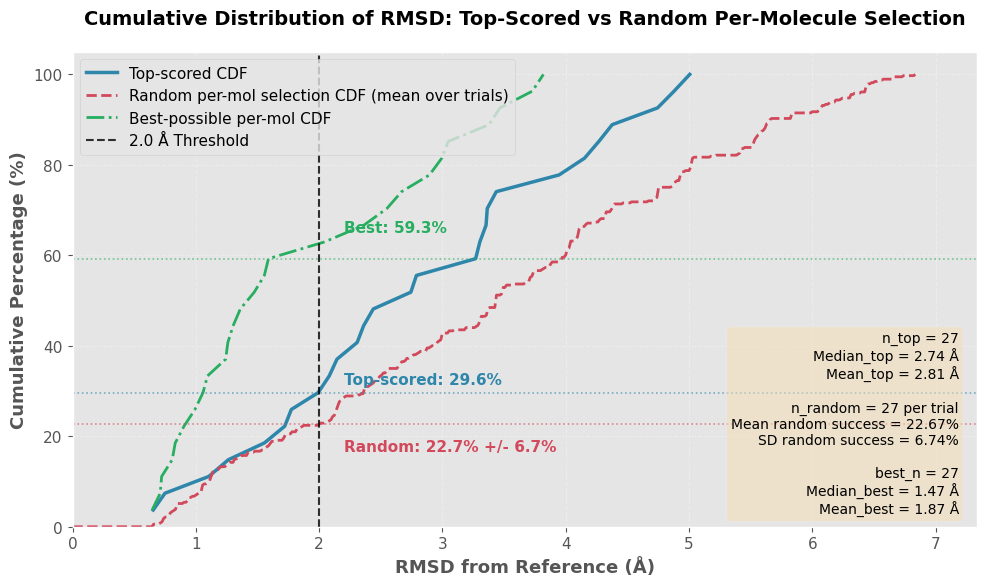

Cumulative distribution statistics (Top-scored):
  7.4% of top-scored molecules have RMSD < 1.0 Å
  14.8% of top-scored molecules have RMSD < 1.5 Å
  29.6% of top-scored molecules have RMSD < 2.0 Å
  48.1% of top-scored molecules have RMSD < 2.5 Å
  55.6% of top-scored molecules have RMSD < 3.0 Å

Cumulative distribution statistics (Random per-mol selection):
  Mean 7.0% +/- 4.1% have RMSD < 1.0 Å
  Mean 16.7% +/- 5.8% have RMSD < 1.5 Å
  Mean 22.7% +/- 6.7% have RMSD < 2.0 Å
  Mean 33.5% +/- 7.6% have RMSD < 2.5 Å
  Mean 42.8% +/- 7.2% have RMSD < 3.0 Å

Cumulative distribution statistics (Best-possible per-mol selection):
  25.9% of best-possible selections have RMSD < 1.0 Å
  51.9% of best-possible selections have RMSD < 1.5 Å
  59.3% of best-possible selections have RMSD < 2.0 Å
  66.7% of best-possible selections have RMSD < 2.5 Å
  81.5% of best-possible selections have RMSD < 3.0 Å


In [30]:
# Prepare data for cumulative distribution (top-scored conformations)
rmsd_values = best_conformations['rmsd'].dropna().sort_values().values
if len(rmsd_values) == 0:
    raise ValueError("No valid top-scored RMSD values available for CDF analysis")
cumulative_pct = np.arange(1, len(rmsd_values) + 1) / len(rmsd_values) * 100

# Compute CDF for random per-molecule selection
np.random.seed(42)
per_mol_rmsds = {}
for mol, grp in abfe_df.groupby('mol_id'):
    vals = grp['rmsd'].dropna().values
    if len(vals) == 0:
        raise ValueError(f"No valid RMSD values for molecule {mol}; random baseline cannot be computed")
    per_mol_rmsds[mol] = vals

n_molecules = len(per_mol_rmsds)
if n_molecules == 0:
    raise ValueError("No per-molecule RMSD data available for random selection CDF")

N_TRIALS = 10_000
mol_keys = sorted(per_mol_rmsds.keys())
sampled_rmsds = np.empty((N_TRIALS, n_molecules), dtype=float)
for t in range(N_TRIALS):
    sampled_rmsds[t, :] = [np.random.choice(per_mol_rmsds[m]) for m in mol_keys]

# Average CDF on a fixed RMSD grid across trials
max_observed_rmsd = max(rmsd_values.max(), sampled_rmsds.max())
x_grid = np.linspace(0, max_observed_rmsd, 500)
trial_cdfs = np.array([
    np.searchsorted(np.sort(trial_rmsds), x_grid, side='right') / len(trial_rmsds) * 100
    for trial_rmsds in sampled_rmsds
])
sampled_cum_pct = trial_cdfs.mean(axis=0)

# Trial-level random success percentages at threshold
random_success_rates = (sampled_rmsds <= RMSD_THRESHOLD).sum(axis=1) / n_molecules * 100
random_success_mean = random_success_rates.mean()
random_success_std = random_success_rates.std(ddof=1)

# Compute best-possible per-molecule CDF (choose lowest RMSD available per molecule)
best_per_mol = np.array([vals.min() for vals in per_mol_rmsds.values()])
best_sorted = np.sort(best_per_mol)
best_cum_pct = np.arange(1, len(best_sorted) + 1) / len(best_sorted) * 100

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot cumulative distribution for top-scored
ax.plot(rmsd_values, cumulative_pct, linewidth=2.5, color='#2E86AB', label='Top-scored CDF')

# Plot random-selection average CDF
ax.plot(x_grid, sampled_cum_pct, linewidth=2.0, color='#D1495B', linestyle='--', label='Random per-mol selection CDF (mean over trials)')

# Plot best-possible per-molecule CDF
ax.plot(best_sorted, best_cum_pct, linewidth=2.0, color='#27AE60', linestyle='-.', label='Best-possible per-mol CDF')

# Add reference line at RMSD threshold
ax.axvline(x=RMSD_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'{RMSD_THRESHOLD} Å Threshold', alpha=0.8)

# Add horizontal line at success rate for top-scored
success_pct_at_threshold = (rmsd_values <= RMSD_THRESHOLD).sum() / len(rmsd_values) * 100
ax.axhline(y=success_pct_at_threshold, color='#2E86AB', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, success_pct_at_threshold + 2,
        f'Top-scored: {success_pct_at_threshold:.1f}%', color='#2E86AB', fontweight='bold')

# Add horizontal line for random-selection mean success
ax.axhline(y=random_success_mean, color='#D1495B', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, random_success_mean - 6,
        f'Random: {random_success_mean:.1f}% +/- {random_success_std:.1f}%', color='#D1495B', fontweight='bold')

# Add horizontal line for best-possible success
best_success_pct = (best_sorted <= RMSD_THRESHOLD).sum() / len(best_sorted) * 100
ax.axhline(y=best_success_pct, color='#27AE60', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(RMSD_THRESHOLD + 0.2, best_success_pct + 6,
        f'Best: {best_success_pct:.1f}%', color='#27AE60', fontweight='bold')

# Labels and formatting
ax.set_xlabel('RMSD from Reference (Å)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('Cumulative Distribution of RMSD: Top-Scored vs Random Per-Molecule Selection',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper left')

# Set axis limits
max_x = min(max(max_observed_rmsd, best_sorted.max()) + 0.5, 10)
ax.set_xlim(0, max_x)
ax.set_ylim(0, 105)

# Add statistics box
stats_text = f'n_top = {len(rmsd_values)}\nMedian_top = {np.median(rmsd_values):.2f} Å\nMean_top = {np.mean(rmsd_values):.2f} Å'
stats_text += f"\n\nn_random = {n_molecules} per trial\nMean random success = {random_success_mean:.2f}%\nSD random success = {random_success_std:.2f}%"
stats_text += f"\n\nbest_n = {len(best_sorted)}\nMedian_best = {np.median(best_sorted):.2f} Å\nMean_best = {np.mean(best_sorted):.2f} Å"
ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print cumulative distribution statistics
print(f"Cumulative distribution statistics (Top-scored):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (rmsd_values <= threshold).sum() / len(rmsd_values) * 100
    print(f"  {pct:.1f}% of top-scored molecules have RMSD < {threshold} Å")

print(f"\nCumulative distribution statistics (Random per-mol selection):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    trial_pct = (sampled_rmsds <= threshold).sum(axis=1) / n_molecules * 100
    print(f"  Mean {trial_pct.mean():.1f}% +/- {trial_pct.std(ddof=1):.1f}% have RMSD < {threshold} Å")

print(f"\nCumulative distribution statistics (Best-possible per-mol selection):")
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (best_sorted <= threshold).sum() / len(best_sorted) * 100
    print(f"  {pct:.1f}% of best-possible selections have RMSD < {threshold} Å")

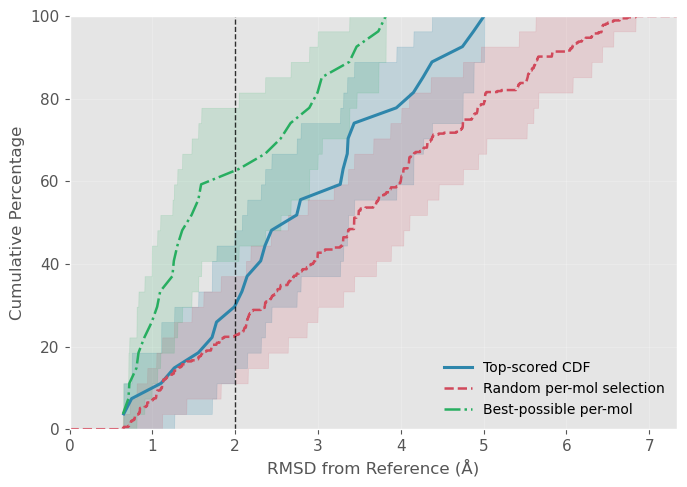

Cumulative distribution statistics (Top-scored):
  7.4% of top-scored molecules have RMSD < 1.0 Å
  14.8% of top-scored molecules have RMSD < 1.5 Å
  29.6% of top-scored molecules have RMSD < 2.0 Å
  48.1% of top-scored molecules have RMSD < 2.5 Å
  55.6% of top-scored molecules have RMSD < 3.0 Å

Cumulative distribution statistics (Random per-mol selection, mean ± sd):
  Mean 806.1% ± 129.1% have RMSD < 1.0 Å
  Mean 806.1% ± 129.1% have RMSD < 1.5 Å
  Mean 806.1% ± 129.1% have RMSD < 2.0 Å
  Mean 806.1% ± 129.1% have RMSD < 2.5 Å
  Mean 806.1% ± 129.1% have RMSD < 3.0 Å

Cumulative distribution statistics (Best-possible per-mol selection):
  25.9% of best-possible selections have RMSD < 1.0 Å
  51.9% of best-possible selections have RMSD < 1.5 Å
  59.3% of best-possible selections have RMSD < 2.0 Å
  66.7% of best-possible selections have RMSD < 2.5 Å
  81.5% of best-possible selections have RMSD < 3.0 Å


In [44]:
# Simplified CDF plot with bootstrapped 95% CI shaded areas
import matplotlib as mpl
plt.style.use('ggplot')
mpl.rcParams.update({'font.size': 11})

# Prepare data for cumulative distribution (top-scored conformations)
# Assume datasets are already cleaned (no NaNs)
rmsd_values = best_conformations['rmsd'].sort_values().values
cumulative_pct = np.arange(1, len(rmsd_values) + 1) / len(rmsd_values) * 100

# Build per-molecule RMSD pools for random baseline
per_mol_rmsds = {mol: grp['rmsd'].values for mol, grp in abfe_df.groupby('mol_id')}

n_molecules = len(per_mol_rmsds)
if n_molecules == 0:
    raise ValueError("No per-molecule RMSD data available for random selection CDF")

# Grid for CDF evaluation
max_observed = max(rmsd_values.max(), max(vals.max() for vals in per_mol_rmsds.values()))
x_grid = np.linspace(0, min(max_observed + 0.5, 10.0), 2000)

# Helper to compute empirical CDF on x_grid (returns fractions in %)
def cdf_on_grid(values, x_grid):
    vals = np.sort(values)
    return np.searchsorted(vals, x_grid, side='right') / vals.size * 100.0

B = 10_000  # bootstrap samples
rng = np.random.default_rng(42)
boot_top = np.empty((B, x_grid.size), dtype=float)
for b in range(B):
    idx = rng.integers(0, rmsd_values.size, rmsd_values.size)
    boot_sample = rmsd_values[idx]
    boot_top[b, :] = cdf_on_grid(boot_sample, x_grid)
boot_top_lower = np.percentile(boot_top, 2.5, axis=0)
boot_top_upper = np.percentile(boot_top, 97.5, axis=0)

# Random per-molecule selection CDF and CI (simulate many random trials)
N_TRIALS = 10_000
trial_cdfs = np.empty((N_TRIALS, x_grid.size), dtype=float)
for t in range(N_TRIALS):
    sampled = np.array([rng.choice(vals) for vals in per_mol_rmsds.values()])
    trial_cdfs[t, :] = cdf_on_grid(sampled, x_grid)
random_cdf_mean = trial_cdfs.mean(axis=0)
random_cdf_lower = np.percentile(trial_cdfs, 2.5, axis=0)
random_cdf_upper = np.percentile(trial_cdfs, 97.5, axis=0)

# Best-possible per-molecule CDF and bootstrap CI
best_rmsd_per_mol = np.array([vals.min() for vals in per_mol_rmsds.values()])
best_rmsd_per_mol_sorted = np.sort(best_rmsd_per_mol)
best_cdf = np.arange(1, len(best_rmsd_per_mol_sorted) + 1) / len(best_rmsd_per_mol_sorted) * 100
boot_best = np.empty((B, x_grid.size), dtype=float)
for b in range(B):
    idx = rng.integers(0, best_rmsd_per_mol.size, best_rmsd_per_mol.size)
    boot_best[b, :] = cdf_on_grid(best_rmsd_per_mol[idx], x_grid)
boot_best_lower = np.percentile(boot_best, 2.5, axis=0)
boot_best_upper = np.percentile(boot_best, 97.5, axis=0)

# Compute success rates at threshold for annotation
success_pct_at_threshold = (rmsd_values <= RMSD_THRESHOLD).sum() / rmsd_values.size * 100
random_success_mean = (trial_cdfs <= RMSD_THRESHOLD).sum(axis=1).mean() / n_molecules * 100
random_success_std = (trial_cdfs <= RMSD_THRESHOLD).sum(axis=1).std(ddof=1) / n_molecules * 100
best_success_pct = (best_rmsd_per_mol <= RMSD_THRESHOLD).sum() / best_rmsd_per_mol.size * 100

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

# Shaded CI areas
ax.fill_between(x_grid, boot_top_lower, boot_top_upper, color='#2E86AB', alpha=0.2)
ax.fill_between(x_grid, random_cdf_lower, random_cdf_upper, color='#D1495B', alpha=0.15)
ax.fill_between(x_grid, boot_best_lower, boot_best_upper, color='#27AE60', alpha=0.15)

# Main lines
ax.plot(rmsd_values, cumulative_pct, linewidth=2.2, color='#2E86AB', label='Top-scored CDF')
ax.plot(x_grid, random_cdf_mean, linewidth=1.8, color='#D1495B', linestyle='--', label='Random per-mol selection')
ax.plot(best_rmsd_per_mol_sorted, best_cdf, linewidth=1.8, color='#27AE60', linestyle='-.', label='Best-possible per-mol')

# Threshold line and annotations
ax.axvline(x=RMSD_THRESHOLD, color='k', linestyle='--', linewidth=1.0, alpha=0.8)
# ax.text(RMSD_THRESHOLD + 0.15, 5, f'{RMSD_THRESHOLD} Å threshold', fontsize=10, color='k')

# Annotations for success rates
# ax.text(0.98, 0.02, f"Top: {success_pct_at_threshold:.1f}%\nRandom: {random_success_mean:.1f}% ± {random_success_std:.1f}%\nBest: {best_success_pct:.1f}%",
#         transform=ax.transAxes, fontsize=10, ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Labels & formatting (ggplot-like simplicity)
ax.set_xlabel('RMSD from Reference (Å)', fontsize=12)
ax.set_ylabel('Cumulative Percentage', fontsize=12)
ax.set_xlim(0, min(x_grid.max(), 10))
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=10)
ax.grid(True, linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

# Print summary stats for key thresholds
print('Cumulative distribution statistics (Top-scored):')
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (rmsd_values <= threshold).sum() / rmsd_values.size * 100
    print(f"  {pct:.1f}% of top-scored molecules have RMSD < {threshold} Å")

print('\nCumulative distribution statistics (Random per-mol selection, mean ± sd):')
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    trial_pct = (trial_cdfs <= threshold).sum(axis=1) / n_molecules * 100
    print(f"  Mean {trial_pct.mean():.1f}% ± {trial_pct.std(ddof=1):.1f}% have RMSD < {threshold} Å")

print('\nCumulative distribution statistics (Best-possible per-mol selection):')
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pct = (best_rmsd_per_mol <= threshold).sum() / best_rmsd_per_mol.size * 100
    print(f"  {pct:.1f}% of best-possible selections have RMSD < {threshold} Å")

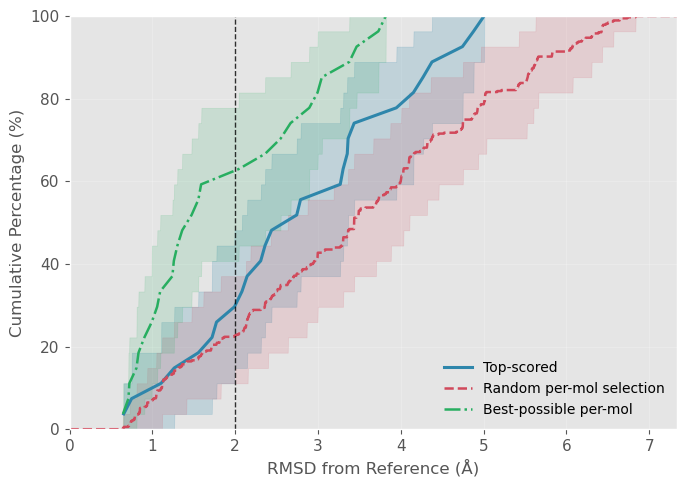

Cumulative distribution statistics (Top-scored):
  7.4% have RMSD < 1.0 Å
  14.8% have RMSD < 1.5 Å
  29.6% have RMSD < 2.0 Å
  48.1% have RMSD < 2.5 Å
  55.6% have RMSD < 3.0 Å

Cumulative distribution statistics (Random per-mol, mean ± sd):
  806.1% ± 129.1% have RMSD < 1.0 Å
  806.1% ± 129.1% have RMSD < 1.5 Å
  806.1% ± 129.1% have RMSD < 2.0 Å
  806.1% ± 129.1% have RMSD < 2.5 Å
  806.1% ± 129.1% have RMSD < 3.0 Å

Cumulative distribution statistics (Best-possible per-mol):
  25.9% have RMSD < 1.0 Å
  51.9% have RMSD < 1.5 Å
  59.3% have RMSD < 2.0 Å
  66.7% have RMSD < 2.5 Å
  81.5% have RMSD < 3.0 Å

Bootstrap superiority test (threshold = 2.0 Å, N=10,000):
  Top-scored vs Random:
    Mean difference: 7.0% | 95% CI [-14.8, 29.6]%
    P(diff > 0) = 0.677  →  ✗ not significant (one-sided bootstrap, α=0.05)
  Best-possible vs Random:
    Mean difference: 36.7% | 95% CI [14.8, 59.3]%
    P(diff > 0) = 0.999  →  ✓ significant (one-sided bootstrap, α=0.05)


In [46]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Configuration ─────────────────────────────────────────────────────────────

RMSD_THRESHOLD = 2.0
X_MAX = 10.0
N_BOOT = 10_000
N_TRIALS = 10_000
RNG_SEED = 42

COLORS = {"top": "#2E86AB", "random": "#D1495B", "best": "#27AE60"}
THRESHOLDS_REPORT = [1.0, 1.5, 2.0, 2.5, 3.0]

# ── Data preparation ───────────────────────────────────────────────────────────

def get_per_mol_rmsds(df):
    return {mol: grp["rmsd"].values for mol, grp in df.groupby("mol_id")}


def build_x_grid(rmsd_values, per_mol_rmsds, x_max=X_MAX, n_points=2000):
    max_observed = max(
        rmsd_values.max(),
        max(v.max() for v in per_mol_rmsds.values()),
    )
    return np.linspace(0, min(max_observed + 0.5, x_max), n_points)


def empirical_cdf(values, x_grid):
    """Fraction of `values` <= each point in `x_grid`, as percentages."""
    vals = np.sort(values)
    return np.searchsorted(vals, x_grid, side="right") / vals.size * 100.0


# ── Bootstrap / Monte Carlo helpers ───────────────────────────────────────────

def bootstrap_cdf(values, x_grid, n_boot=N_BOOT, rng=None):
    """Bootstrap 95% CI bands for an empirical CDF. Returns (lower, upper)."""
    rng = rng or np.random.default_rng(RNG_SEED)
    boot = np.empty((n_boot, x_grid.size))
    for b in range(n_boot):
        idx = rng.integers(0, values.size, values.size)
        boot[b] = empirical_cdf(values[idx], x_grid)
    return np.percentile(boot, [2.5, 97.5], axis=0)


def simulate_random_selection(per_mol_rmsds, x_grid, n_trials=N_TRIALS, rng=None):
    """Monte Carlo CDF for random per-molecule conformation selection.

    Returns
    -------
    mean_cdf    : (n_grid,) mean CDF across trials
    ci_lower    : (n_grid,) 2.5th percentile
    ci_upper    : (n_grid,) 97.5th percentile
    trial_cdfs  : (n_trials, n_grid) all per-trial CDFs (needed for significance test)
    """
    rng = rng or np.random.default_rng(RNG_SEED)
    mol_pools = list(per_mol_rmsds.values())
    trial_cdfs = np.empty((n_trials, x_grid.size))
    for t in range(n_trials):
        sampled = np.array([rng.choice(pool) for pool in mol_pools])
        trial_cdfs[t] = empirical_cdf(sampled, x_grid)
    lower, upper = np.percentile(trial_cdfs, [2.5, 97.5], axis=0)
    return trial_cdfs.mean(axis=0), lower, upper, trial_cdfs


# ── Statistical significance test ─────────────────────────────────────────────

def success_rate(rmsds, threshold=RMSD_THRESHOLD):
    """Fraction of RMSDs <= threshold, as a percentage."""
    return np.mean(rmsds <= threshold) * 100.0


def bootstrap_superiority_test(top_rmsds, best_rmsds, trial_cdfs,
                                x_grid, threshold=RMSD_THRESHOLD,
                                n_boot=N_BOOT, rng=None):
    """Test whether top-scored and best-possible selections are significantly
    better than random selection at threshold `threshold`.

    Strategy
    --------
    For each bootstrap iteration:
      - Resample top_rmsds / best_rmsds with replacement → compute success rate.
      - Draw one random trial from trial_cdfs (Monte Carlo proxy for random
        selection) → read off success rate at threshold from the CDF.
      - Record the difference (method − random).

    A method is considered significantly better if > 95% of bootstrap
    differences are positive (one-sided bootstrap p < 0.05).

    Returns a dict with the difference distributions and empirical p-values.
    """
    rng = rng or np.random.default_rng(RNG_SEED)

    # Pre-compute per-trial success rates for random selection
    # Find the x_grid index closest to threshold, then read the CDF value there
    threshold_idx = np.searchsorted(x_grid, threshold, side="right") - 1
    threshold_idx = np.clip(threshold_idx, 0, x_grid.size - 1)
    random_success_rates = trial_cdfs[:, threshold_idx]  # shape (n_trials,)

    results = {}
    for label, rmsds in [("top_vs_random", top_rmsds), ("best_vs_random", best_rmsds)]:
        diffs = np.empty(n_boot)
        for b in range(n_boot):
            resampled = rng.choice(rmsds, size=rmsds.size, replace=True)
            method_rate = success_rate(resampled, threshold)
            rand_rate = random_success_rates[rng.integers(0, random_success_rates.size)]
            diffs[b] = method_rate - rand_rate
        p_gt0 = np.mean(diffs > 0)
        results[label] = {"diffs": diffs, "p_gt0": p_gt0}

    return results


# ── Plotting ───────────────────────────────────────────────────────────────────

def plot_cdf(ax, rmsd_values, x_grid,
             top_ci, random_mean_cdf, random_ci,
             best_rmsds, best_ci,
             threshold=RMSD_THRESHOLD):

    best_rmsds_sorted = np.sort(best_rmsds)
    best_cdf = np.arange(1, best_rmsds.size + 1) / best_rmsds.size * 100

    # CI shading
    ax.fill_between(x_grid, top_ci[0], top_ci[1], color=COLORS["top"], alpha=0.2)
    ax.fill_between(x_grid, random_ci[0], random_ci[1], color=COLORS["random"], alpha=0.15)
    ax.fill_between(x_grid, best_ci[0], best_ci[1], color=COLORS["best"], alpha=0.15)

    # Main lines
    rmsd_sorted = np.sort(rmsd_values)
    top_cdf = np.arange(1, rmsd_sorted.size + 1) / rmsd_sorted.size * 100
    ax.plot(rmsd_sorted, top_cdf, lw=2.2, color=COLORS["top"], label="Top-scored")
    ax.plot(x_grid, random_mean_cdf, lw=1.8, color=COLORS["random"],
            ls="--", label="Random per-mol selection")
    ax.plot(best_rmsds_sorted, best_cdf, lw=1.8, color=COLORS["best"],
            ls="-.", label="Best-possible per-mol")

    ax.axvline(threshold, color="k", ls="--", lw=1.0, alpha=0.8)
    ax.set_xlabel("RMSD from Reference (Å)", fontsize=12)
    ax.set_ylabel("Cumulative Percentage (%)", fontsize=12)
    ax.set_xlim(0, x_grid.max())
    ax.set_ylim(0, 100)
    ax.legend(frameon=False, fontsize=10)
    ax.grid(True, ls="-", alpha=0.2)


# ── Summary printing ───────────────────────────────────────────────────────────

def print_cdf_summary(top_rmsds, best_rmsds, trial_cdfs, n_mols,
                      thresholds=THRESHOLDS_REPORT):
    print("Cumulative distribution statistics (Top-scored):")
    for t in thresholds:
        pct = success_rate(top_rmsds, t)
        print(f"  {pct:.1f}% have RMSD < {t} Å")

    print("\nCumulative distribution statistics (Random per-mol, mean ± sd):")
    for t in thresholds:
        trial_pct = (trial_cdfs <= t).sum(axis=1) / n_mols * 100
        print(f"  {trial_pct.mean():.1f}% ± {trial_pct.std(ddof=1):.1f}% have RMSD < {t} Å")

    print("\nCumulative distribution statistics (Best-possible per-mol):")
    for t in thresholds:
        pct = success_rate(best_rmsds, t)
        print(f"  {pct:.1f}% have RMSD < {t} Å")


def print_significance(sig_results, threshold=RMSD_THRESHOLD):
    print(f"\nBootstrap superiority test (threshold = {threshold} Å, N={N_BOOT:,}):")
    labels = {"top_vs_random": "Top-scored vs Random",
              "best_vs_random": "Best-possible vs Random"}
    for key, res in sig_results.items():
        diffs = res["diffs"]
        p = res["p_gt0"]
        sig = "✓ significant" if p >= 0.95 else "✗ not significant"
        print(f"  {labels[key]}:")
        print(f"    Mean difference: {diffs.mean():.1f}% | 95% CI [{np.percentile(diffs, 2.5):.1f}, {np.percentile(diffs, 97.5):.1f}]%")
        print(f"    P(diff > 0) = {p:.3f}  →  {sig} (one-sided bootstrap, α=0.05)")


# ── Main ───────────────────────────────────────────────────────────────────────

def main():
    plt.style.use("ggplot")
    mpl.rcParams.update({"font.size": 11})
    rng = np.random.default_rng(RNG_SEED)

    # ── Prepare data
    top_rmsds = best_conformations["rmsd"].sort_values().values
    per_mol_rmsds = get_per_mol_rmsds(abfe_df)
    if not per_mol_rmsds:
        raise ValueError("No per-molecule RMSD data found.")

    best_rmsds = np.array([v.min() for v in per_mol_rmsds.values()])
    x_grid = build_x_grid(top_rmsds, per_mol_rmsds)

    # ── Compute CDFs and CIs
    top_ci = bootstrap_cdf(top_rmsds, x_grid, rng=rng)
    random_mean_cdf, random_ci_lower, random_ci_upper, trial_cdfs = simulate_random_selection(
        per_mol_rmsds, x_grid, rng=rng
    )
    best_ci = bootstrap_cdf(best_rmsds, x_grid, rng=rng)

    # ── Plot
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_cdf(ax, top_rmsds, x_grid,
             top_ci, random_mean_cdf, (random_ci_lower, random_ci_upper),
             best_rmsds, best_ci)
    plt.tight_layout()
    plt.show()

    # ── Summary statistics
    print_cdf_summary(top_rmsds, best_rmsds, trial_cdfs, len(per_mol_rmsds))

    # ── Significance test
    sig_results = bootstrap_superiority_test(
        top_rmsds, best_rmsds, trial_cdfs, x_grid, rng=rng
    )
    print_significance(sig_results)


main()

In [ ]:
# Test if ABFE scoring produces statistically significantly better RMSD < 2 A than random per-molecule selection using a paired bootstrap test
threshold = 2.0
n_bootstrap = 10_000

def get_samples_below_threshold(rmsd_values, threshold):
    return (rmsd_values <= threshold).sum() / len(rmsd_values)

def 


Bootstrap test for RMSD < 2.0 Å:
  Top-scored success rate: 0.296
  Random per-mol selection mean success rate: 0.227 ± 0.068
  p-value: 0.2233 (proportion of random trials with success >= top-scored)


## 9. Additional Visualizations

Explore the relationship between ABFE scores and RMSD values.

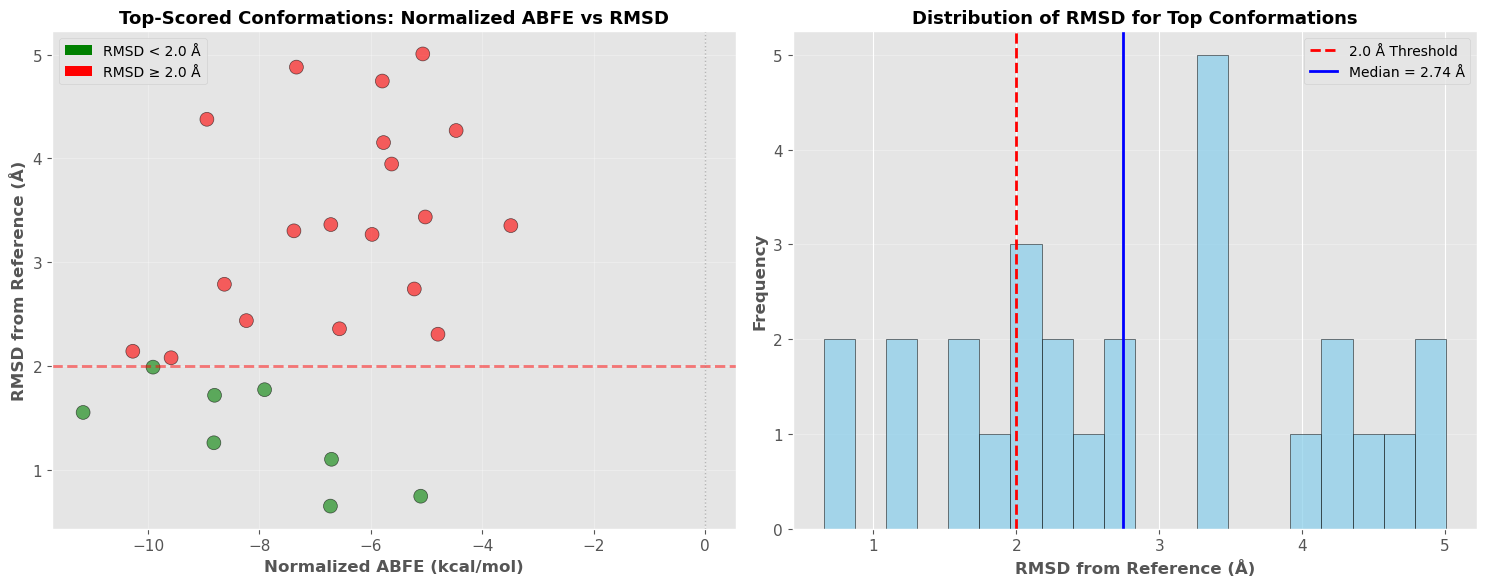

In [19]:
# Scatter plot: ABFE score vs RMSD for top conformations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: dG vs RMSD for top conformations (using normalized ABFE)
valid_data = best_conformations.dropna(subset=['rmsd', 'mean_dg_normalized'])
colors = ['green' if rmsd < RMSD_THRESHOLD else 'red' for rmsd in valid_data['rmsd']]

ax1.scatter(valid_data['mean_dg_normalized'], valid_data['rmsd'], 
           c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
ax1.axhline(y=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Normalized ABFE (kcal/mol)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax1.set_title('Top-Scored Conformations: Normalized ABFE vs RMSD', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label=f'RMSD < {RMSD_THRESHOLD} Å'),
                   Patch(facecolor='red', label=f'RMSD ≥ {RMSD_THRESHOLD} Å')]
ax1.legend(handles=legend_elements, fontsize=10)

# Plot 2: Histogram of RMSD values
ax2.hist(valid_data['rmsd'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2, 
           label=f'{RMSD_THRESHOLD} Å Threshold')
ax2.axvline(x=valid_data['rmsd'].median(), color='blue', linestyle='-', linewidth=2,
           label=f'Median = {valid_data["rmsd"].median():.2f} Å')
ax2.set_xlabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of RMSD for Top Conformations', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 9.1 All Conformations Analysis

Analyze the relationship between ABFE scores and RMSD for all conformations (not just top-scored).

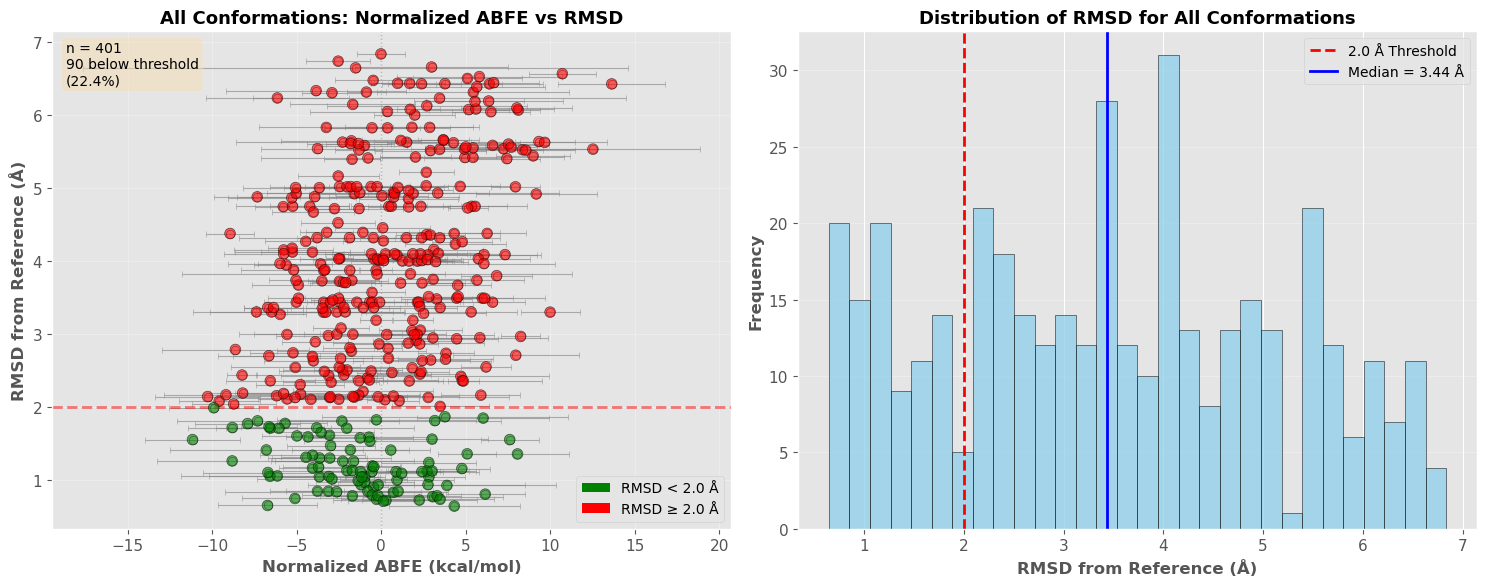

Comparison: All Conformations vs Top-Scored Only
All conformations:
  Total: 401
  Mean RMSD: 3.46 Å
  Median RMSD: 3.44 Å
  Success rate: 22.4%

Top-scored conformations only:
  Total (valid RMSD): 27
  Mean RMSD: 2.81 Å
  Median RMSD: 2.74 Å
  Success rate: 29.6%


In [20]:
# Scatter plot: ABFE score vs RMSD for ALL conformations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: dG vs RMSD for all conformations (using normalized ABFE)
all_valid_data = abfe_df.dropna(subset=['rmsd', 'mean_dg_normalized'])
if len(all_valid_data) == 0:
    raise ValueError("No valid rows with both RMSD and normalized ABFE")

colors_all = ['green' if rmsd < RMSD_THRESHOLD else 'red' for rmsd in all_valid_data['rmsd']]

# Plot with error bars
ax1.errorbar(all_valid_data['mean_dg_normalized'], all_valid_data['rmsd'],
            xerr=all_valid_data['error'], fmt='o', markersize=6,
            ecolor='gray', elinewidth=0.8, capsize=2, capthick=0.8,
            alpha=0.6, color='none', markeredgewidth=0.5, markeredgecolor='black')

# Color the markers
ax1.scatter(all_valid_data['mean_dg_normalized'], all_valid_data['rmsd'],
           c=colors_all, alpha=0.6, s=60, edgecolors='black', linewidth=0.5, zorder=3)

ax1.axhline(y=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Normalized ABFE (kcal/mol)', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax1.set_title('All Conformations: Normalized ABFE vs RMSD', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label=f'RMSD < {RMSD_THRESHOLD} Å'),
                   Patch(facecolor='red', label=f'RMSD ≥ {RMSD_THRESHOLD} Å')]
ax1.legend(handles=legend_elements, fontsize=10)

# Add statistics text
n_success_all = (all_valid_data['rmsd'] < RMSD_THRESHOLD).sum()
success_rate_all = n_success_all / len(all_valid_data) * 100
stats_text = f'n = {len(all_valid_data)}\n{n_success_all} below threshold\n({success_rate_all:.1f}%)'
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Histogram of RMSD values for all conformations
ax2.hist(all_valid_data['rmsd'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=RMSD_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'{RMSD_THRESHOLD} Å Threshold')
ax2.axvline(x=all_valid_data['rmsd'].median(), color='blue', linestyle='-', linewidth=2,
           label=f'Median = {all_valid_data["rmsd"].median():.2f} Å')
ax2.set_xlabel('RMSD from Reference (Å)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of RMSD for All Conformations', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics comparison
print(f"Comparison: All Conformations vs Top-Scored Only")
print(f"="*60)
print(f"All conformations:")
print(f"  Total: {len(all_valid_data)}")
print(f"  Mean RMSD: {all_valid_data['rmsd'].mean():.2f} Å")
print(f"  Median RMSD: {all_valid_data['rmsd'].median():.2f} Å")
print(f"  Success rate: {success_rate_all:.1f}%")

valid_top = best_conformations.dropna(subset=['rmsd'])
if len(valid_top) == 0:
    raise ValueError("No valid RMSD values in best_conformations")

top_success_rate = (valid_top['rmsd'] < RMSD_THRESHOLD).sum() / len(valid_top) * 100
print(f"\nTop-scored conformations only:")
print(f"  Total (valid RMSD): {len(valid_top)}")
print(f"  Mean RMSD: {valid_top['rmsd'].mean():.2f} Å")
print(f"  Median RMSD: {valid_top['rmsd'].median():.2f} Å")
print(f"  Success rate: {top_success_rate:.1f}%")

In [21]:
from openff.toolkit import Molecule

def visualise(df: pd.DataFrame, mol_id: str, receptor_id: str) -> Molecule:
    filtered_df = df[(df['mol_id'] == mol_id) & (df['receptor_id'] == receptor_id)]
    sdf_path = filtered_df["ligand_sdf_path"].values[0]
    print(sdf_path)
    molecule = Molecule.from_file(sdf_path)
    return molecule


visualise(all_valid_data, "mol3", "rec_final_20")

/home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/../input/fegrow_result/rec_20_mol3.sdf


/home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/../input/fegrow_result/rec_20_mol3.sdf


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/a3fe/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


NGLWidget()

In [22]:
visualise(all_valid_data, "mol3", "rec_final_7")

/home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/../input/fegrow_result/rec_7_mol3.sdf


NGLWidget()

In [23]:
all_valid_data.sort_values('mean_dg', inplace=True)
all_valid_data

,mol_id,receptor_id,mean_dg,error,stats_path,ligand_sdf_path,mol_dir,rec_dir,rmsd,mean_dg_normalized
195,mol30,rec_final_20,-27.422,4.475,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,1.263781,-8.818786
30,mol13,rec_final_19,-25.721,4.363,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.789005,-8.629600
281,mol39,rec_final_20,-25.549,2.802,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,1.555697,-11.165625
196,mol30,rec_final_19,-25.252,3.009,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.703172,-6.648786
343,mol44,rec_final_19,-24.999,3.124,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,2.144387,-10.273929
...,...,...,...,...,...,...,...,...,...,...
58,mol16,rec_final_2,-3.390,3.568,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.490439,6.111333
385,mol7,rec_final_2,-2.529,2.798,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.738828,5.657267
356,mol44,rec_final_18,-2.205,6.344,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,5.531495,12.520071
386,mol7,rec_final_12,-2.114,4.222,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,/home/campus.ncl.ac.uk/nfc78/research/polaris_...,3.965821,6.072267


## 10. Per-Molecule Analysis

Examine ABFE scores and RMSD values across different receptor conformations for each molecule.

In [24]:
# Show detailed analysis for each molecule
print("Per-Molecule Summary:")
print("="*90)

for mol_id in sorted(abfe_df['mol_id'].unique()):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id].copy()
    
    # Get best entry
    best_idx = mol_data['mean_dg'].idxmin()
    best_entry = mol_data.loc[best_idx]
    
    print(f"\n{mol_id}:")
    print(f"  Number of receptor conformations tested: {len(mol_data)}")
    print(f"  Best receptor: {best_entry['receptor_id']}")
    print(f"  Best ABFE: {best_entry['mean_dg']:.2f} ± {best_entry['error']:.2f} kcal/mol")
    print(f"  RMSD at best ABFE: {best_entry['rmsd']:.2f} Å")
    print(f"  Success: {'✓' if best_entry['rmsd'] < RMSD_THRESHOLD else '✗'}")
    
    # Show range of dG and RMSD
    print(f"  dG range: {mol_data['mean_dg'].min():.2f} to {mol_data['mean_dg'].max():.2f} kcal/mol")
    print(f"  RMSD range: {mol_data['rmsd'].min():.2f} to {mol_data['rmsd'].max():.2f} Å")
    
    # Best RMSD in any conformation
    best_rmsd_idx = mol_data['rmsd'].idxmin()
    best_rmsd_entry = mol_data.loc[best_rmsd_idx]
    if best_rmsd_idx != best_idx:
        print(f"  (Best RMSD {best_rmsd_entry['rmsd']:.2f} Å found in {best_rmsd_entry['receptor_id']} with dG={best_rmsd_entry['mean_dg']:.2f})")

print("\n" + "="*90)

Per-Molecule Summary:

mol11:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_9
  Best ABFE: -15.96 ± 1.91 kcal/mol
  RMSD at best ABFE: 3.44 Å
  Success: ✗
  dG range: -15.96 to -4.36 kcal/mol
  RMSD range: 3.38 to 4.23 Å
  (Best RMSD 3.38 Å found in rec_final_6 with dG=-8.67)

mol12:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_19
  Best ABFE: -16.98 ± 1.51 kcal/mol
  RMSD at best ABFE: 3.27 Å
  Success: ✗
  dG range: -16.98 to -4.74 kcal/mol
  RMSD range: 3.05 to 4.39 Å
  (Best RMSD 3.05 Å found in rec_final_15 with dG=-9.19)

mol13:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_19
  Best ABFE: -25.72 ± 4.36 kcal/mol
  RMSD at best ABFE: 2.79 Å
  Success: ✗
  dG range: -25.72 to -3.46 kcal/mol
  RMSD range: 1.26 to 6.43 Å
  (Best RMSD 1.26 Å found in rec_final_16 with dG=-19.37)

mol16:
  Number of receptor conformations tested: 15
  Best receptor: rec_final_6
  Best ABFE: -16.88 ± 2.75 kcal/mol
  RMSD a

In [25]:
def compute_fraction_best_ligands_from_rankings(y_true, y_pred, fraction=0.5):
    """
    Compute fraction-best-ligands using rank overlap.

    Parameters
    ----------
    y_true : array-like
        True values where lower is better (RMSD here).
    y_pred : array-like
        Predicted values where lower is better (ABFE here; more negative is better).
    fraction : float
        Fraction of ligands to evaluate.

    Returns
    -------
    float
        Average overlap coefficient from k=1..floor(n*fraction).
    """
    if not (0 <= fraction <= 1):
        raise ValueError("Fraction must be between 0 and 1.")

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")
    if y_true.ndim != 1:
        raise ValueError("y_true and y_pred must be 1D arrays")
    if len(y_true) == 0:
        raise ValueError("Cannot compute metric on empty arrays")

    # Make sure every value is valid and raise an error if not
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.all(valid):
        raise ValueError("y_true and y_pred must contain only finite values")

    n = len(y_true)

    num_best = round(np.floor(n * fraction))
    if num_best < 1:
        raise ValueError(f"fraction={fraction} yields zero top-ranked entries for n={n}")

    true_ranked = np.argsort(y_true)  # lower RMSD is better
    pred_ranked = np.argsort(y_pred)  # lower ABFE (more negative) is better

    overlap_coefficients = []
    for k in range(1, num_best + 1):
        top_true = set(true_ranked[:k])
        top_pred = set(pred_ranked[:k])
        overlap = len(top_true.intersection(top_pred)) / k
        overlap_coefficients.append(overlap)

    return float(np.mean(overlap_coefficients))


# Compute metric per molecule: rank poses by RMSD (true) and ABFE (pred)
FRACTION_BEST = 0.5
per_mol_fraction_best = []

for mol_id in sorted(abfe_df['mol_id'].unique(), key=lambda x: int(x.replace('mol', ''))):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id].dropna(subset=['rmsd', 'mean_dg']).copy()

    if len(mol_data) < 2:
        raise ValueError(f"Need at least 2 conformations with finite RMSD and mean_dg for {mol_id}; found {len(mol_data)}")

    fb = compute_fraction_best_ligands_from_rankings(
        y_true=mol_data['rmsd'].to_numpy(),
        y_pred=mol_data['mean_dg'].to_numpy(),
        fraction=FRACTION_BEST,
    )

    per_mol_fraction_best.append({
        'mol_id': mol_id,
        'n_conformations': len(mol_data),
        'fraction_best': fb,
    })

fraction_best_df = pd.DataFrame(per_mol_fraction_best).sort_values('mol_id').reset_index(drop=True)

print("Fraction-Best-Ligand (RMSD truth vs ABFE ranking)")
print("=" * 70)
print(f"Fraction evaluated: {FRACTION_BEST}")
print(fraction_best_df.to_string(index=False))

overall_fraction_best_mean = fraction_best_df['fraction_best'].mean()
overall_fraction_best_median = fraction_best_df['fraction_best'].median()
print("\nOverall summary:")
print(f"  Mean fraction-best-ligand: {overall_fraction_best_mean:.4f}")
print(f"  Median fraction-best-ligand: {overall_fraction_best_median:.4f}")

Fraction-Best-Ligand (RMSD truth vs ABFE ranking)
Fraction evaluated: 0.5
mol_id  n_conformations  fraction_best
 mol11               15       0.201701
 mol12               15       0.149320
 mol13               15       0.339116
 mol16               15       0.318707
 mol17               16       0.275446
 mol18               15       0.245918
 mol20               15       0.584014
 mol21               13       0.372222
 mol22               16       0.149256
 mol25               15       0.453061
 mol26               15       0.380272
 mol27               15       0.225510
  mol3               15       0.193537
 mol30               14       0.129252
 mol33               15       0.364966
 mol34               14       0.298299
 mol35               15       0.293537
 mol36               13       0.302778
 mol37               15       0.310204
 mol39               16       0.462202
  mol4               15       0.128912
 mol40               15       0.561565
 mol43               16      

In [26]:
# Check what the random value is by computing fraction-best-ligand for random rankings 10000 times and averaging
from tqdm import tqdm
np.random.seed(42)
random_fraction_bests = []
for _ in tqdm(range(1000)):
    random_fraction_bests.append(
        compute_fraction_best_ligands_from_rankings(
            y_true=abfe_df['rmsd'].to_numpy(),
            y_pred=np.random.permutation(abfe_df['mean_dg'].to_numpy()),
            fraction=FRACTION_BEST,
        )
    )
random_fraction_best_mean = np.mean(random_fraction_bests)
random_fraction_best_std = np.std(random_fraction_bests, ddof=1)
print(f"\nRandom baseline (mean ± std over 10,000 random permutations): {random_fraction_best_mean:.4f} ± {random_fraction_best_std:.4f}")

100%|██████████| 1000/1000 [00:02<00:00, 404.66it/s]

100%|██████████| 1000/1000 [00:02<00:00, 404.66it/s]


Random baseline (mean ± std over 10,000 random permutations): 0.2496 ± 0.0236


## 11. Look at the average spread of ABFE scores per molecule and compare this to the intra-compound variance

In [27]:
# Calculate per-molecule statistics
per_mol_stats = []

for mol_id in sorted(abfe_df['mol_id'].unique()):
    mol_data = abfe_df[abfe_df['mol_id'] == mol_id].copy()
    
    # Inter-receptor spread: standard deviation of mean_dg across different receptors
    dg_range = mol_data['mean_dg'].max() - mol_data['mean_dg'].min()
    
    # Average intra-compound uncertainty: mean of the error values
    # Note: errors are 95% Gaussian-based confidence intervals
    # To get standard error: CI_95 ≈ 1.96 * SE, so SE ≈ CI_95 / 1.96
    avg_error = mol_data['error'].mean()
    avg_std_error = avg_error / 1.96  # Convert 95% CI to standard error
    
    per_mol_stats.append({
        'mol_id': mol_id,
        'n_receptors': len(mol_data),
        'dg_range': dg_range,
        'avg_std_error': avg_std_error
    })

per_mol_df = pd.DataFrame(per_mol_stats)

print("\nPer-Molecule Statistics:")
print(per_mol_df.to_string(index=False))

# Print the average range of ABFE scores for each receptor, and the average std deviation for each molecule for a given receptor
avg_dg_range = per_mol_df['dg_range'].mean()
avg_dg_std_error = per_mol_df['avg_std_error'].mean()
print(f"\nAverage ABFE range across receptors per molecule: {avg_dg_range:.2f} kcal/mol")
print(f"Average ABFE standard error of dG results for a given complex: {avg_dg_std_error:.2f} kcal/mol")


Per-Molecule Statistics:
mol_id  n_receptors  dg_range  avg_std_error
 mol11           15    11.605       1.268673
 mol12           15    12.242       1.227993
 mol13           15    22.262       1.721973
 mol16           15    17.369       1.384150
 mol17           16    16.912       1.251881
 mol18           15    11.351       1.120748
 mol20           15    10.797       1.389898
 mol21           13    14.969       1.526570
 mol22           16    11.621       1.043048
 mol25           15    16.260       1.678707
 mol26           15    13.100       1.272449
 mol27           15    14.684       1.656088
  mol3           15    11.052       1.712041
 mol30           14    19.530       1.580357
 mol33           15    11.511       1.352109
 mol34           14    12.528       1.509985
 mol35           15    16.505       1.666599
 mol36           13    11.564       1.240345
 mol37           15    13.008       1.407585
 mol39           16    20.835       1.336862
  mol4           15     9.378

## 12. Check for correlation of ligand RMSD to reference vs ligand + pocket RMSD to reference

## 11. Export Results

Save the complete analysis results to CSV files for further use.

In [28]:
# Export full results
output_dir = BASE_DIR / "analysis_results"
output_dir.mkdir(parents=True, exist_ok=True)

# Save complete dataframe
full_results_path = output_dir / "abfe_complete_results.csv"
abfe_df[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd']].to_csv(full_results_path, index=False)
print(f"Saved complete results to: {full_results_path}")

# Save best conformations only
best_results_path = output_dir / "abfe_best_conformations.csv"
best_conformations[['mol_id', 'receptor_id', 'mean_dg', 'error', 'rmsd']].to_csv(best_results_path, index=False)
print(f"Saved best conformations to: {best_results_path}")

# Save summary statistics
summary_path = output_dir / "abfe_summary_stats.txt"
with open(summary_path, 'w') as f:
    f.write("ABFE Rescoring Analysis Summary\n")
    f.write("="*60 + "\n\n")
    f.write(f"Total ABFE calculations: {len(abfe_df)}\n")
    f.write(f"Unique molecules: {abfe_df['mol_id'].nunique()}\n")
    f.write(f"Unique receptors: {abfe_df['receptor_id'].nunique()}\n\n")
    f.write(f"RMSD Threshold: {RMSD_THRESHOLD} Å\n")
    f.write(f"Success Rate: {success_rate:.1f}%\n")
    f.write(f"Molecules with RMSD < {RMSD_THRESHOLD} Å: {successful.sum()}/{valid_predictions.sum()}\n\n")
    f.write(f"Mean ABFE (best conformations): {best_conformations['mean_dg'].mean():.2f} kcal/mol\n")
    f.write(f"Mean RMSD (best conformations): {best_conformations['rmsd'].mean():.2f} Å\n")
    f.write(f"Median RMSD (best conformations): {best_conformations['rmsd'].median():.2f} Å\n")

print(f"Saved summary statistics to: {summary_path}")
print("\nAnalysis complete!")

Saved complete results to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/abfe_complete_results.csv
Saved best conformations to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/abfe_best_conformations.csv


Saved complete results to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/abfe_complete_results.csv
Saved best conformations to: /home/campus.ncl.ac.uk/nfc78/research/polaris_retrospective/mers-abfe-rescoring/mers-abfe-rescoring/analysis_results/abfe_best_conformations.csv


NameError: name 'valid_predictions' is not defined